In [280]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import yaml
import csv
from collections import OrderedDict

from pathlib import Path


In [ ]:
NOTEBOOK_DIR: Path = Path.cwd()
PROJECT_ROOT: Path = NOTEBOOK_DIR.parent
CONFIG_PATH: Path = PROJECT_ROOT / "config" / "alignment.yml"

with open(CONFIG_PATH, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)


FINAL_ACCESSIONS = PROJECT_ROOT / (config["paths"]["accession_tsv"])

POLYMERASE_BEFORE_CDHIT_TSV = PROJECT_ROOT / (config["paths"]["polymerase_before_cdhit_tsv"])
VP1_BEFORE_CDHIT_TSV = PROJECT_ROOT / (config["paths"]["vp1_before_cdhit_tsv"])

POLYMERASE_ACCESSIONS = PROJECT_ROOT / (config["paths"]["final_rdrp_accession_tsv"])
VP1_ACCESSIONS = PROJECT_ROOT / (config["paths"]["final_vp1_accession_tsv"])

MERGED_CSV = PROJECT_ROOT / (config["paths"]["merged_csv"])


In [282]:
accessions_complete = set()
accessions_rdrp_before_cdhit = set()
accessions_vp1_before_cdhit = set()

df_acc = pd.read_csv(FINAL_ACCESSIONS)
df_pa_polymerase_before_cdhit = pd.read_csv(POLYMERASE_BEFORE_CDHIT_TSV)
df_pa_vp1_before_cdhit = pd.read_csv(VP1_BEFORE_CDHIT_TSV)


# adderar accessions för sekvsenr i complete_global
for index, row in df_acc.iterrows():
    # print(row)
    # print()
    accessions_complete.add(row['accession'])

# adderar accessions för sekvsner i partial rdrp
for index, row in df_pa_polymerase_before_cdhit.iterrows():

     accessions_rdrp_before_cdhit.add(row['accession'])

print(len(accessions_rdrp_before_cdhit))

# adderar accessions för sekvsner i partial vp1
for index, row in df_pa_vp1_before_cdhit.iterrows():
    accessions_vp1_before_cdhit.add(row['accession'])


400


## För global alignment (full genom)

In [283]:
genotype_dict = {}
p_type_dict = {}

df_complete_spec = pd.read_csv(MERGED_CSV)

for index, row in df_complete_spec.iterrows():
    if row['accession'] in accessions_complete:
        
        if row["p_type"] in p_type_dict:
            p_type_dict[str(row["p_type"])] += 1
        else:
            p_type_dict[str(row["p_type"])] = 1
       
        if row["genotype"] in genotype_dict:
            genotype_dict[str(row["genotype"])] += 1
        else:
            genotype_dict[str(row["genotype"])] = 1



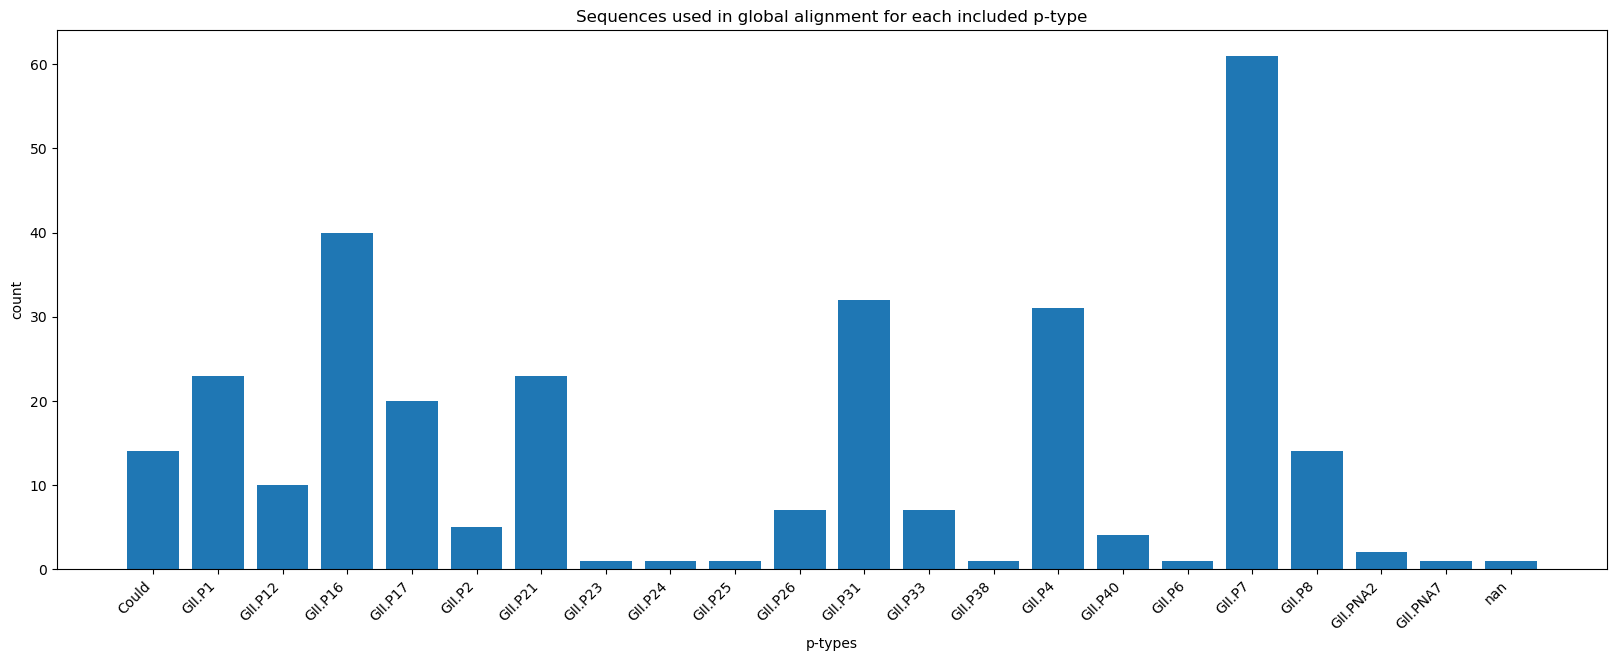

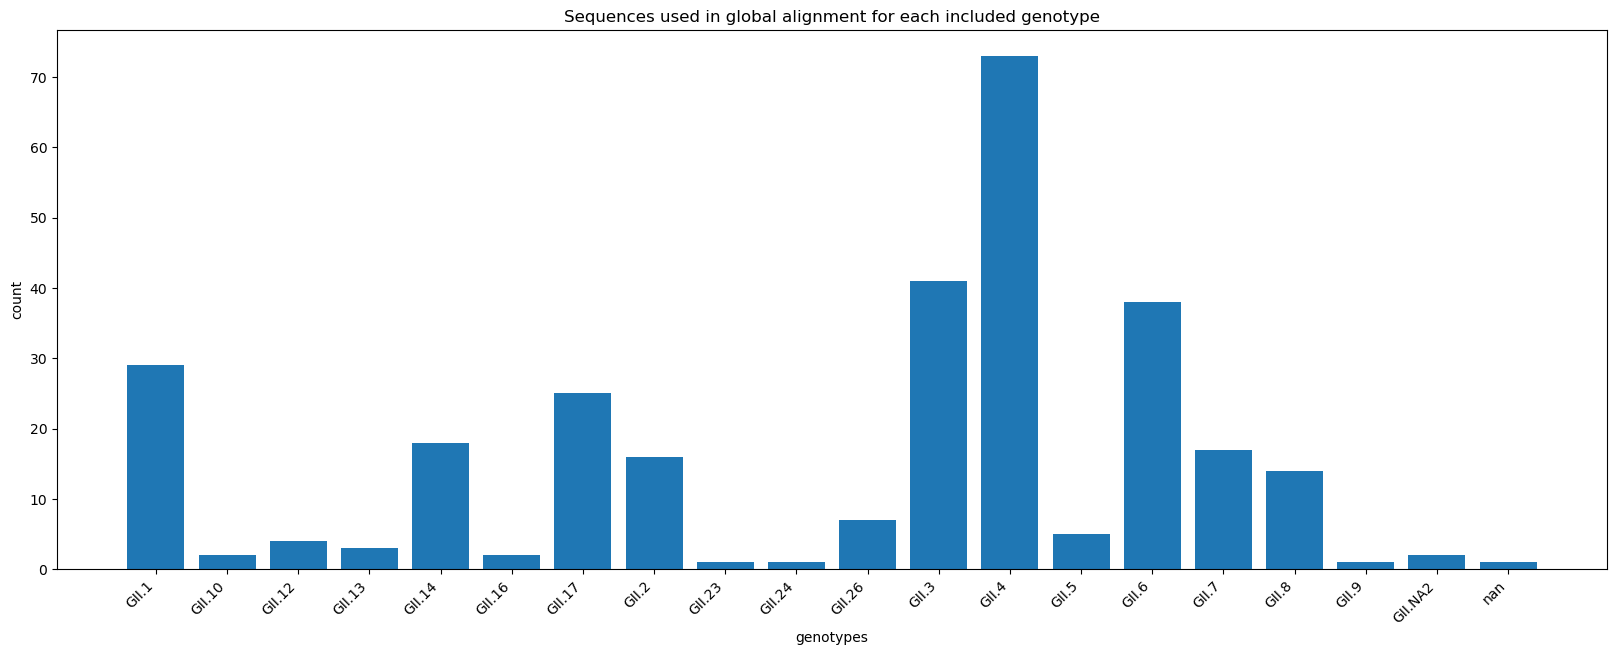

Number of full genome sequences used in global alignemnt: 332


In [284]:
p_types = OrderedDict(sorted(p_type_dict.items(), key = lambda item:item[0]))
genotypes = OrderedDict(sorted(genotype_dict.items(), key = lambda item:item[0]))


plt.figure(figsize=(20, 7))
plt.bar(list(p_types.keys()), list(p_types.values()))
plt.xlabel('p-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included p-type')
plt.show()


plt.figure(figsize=(20, 7))
plt.bar(list(genotypes.keys()), list(genotypes.values()))
plt.xlabel('genotypes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Sequences used in global alignment for each included genotype')
plt.show()

print(f'Number of full genome sequences used in global alignemnt: {len(accessions_complete)}')


## För rdrp-alignment (rdrp-regioner) innan CD-HIT

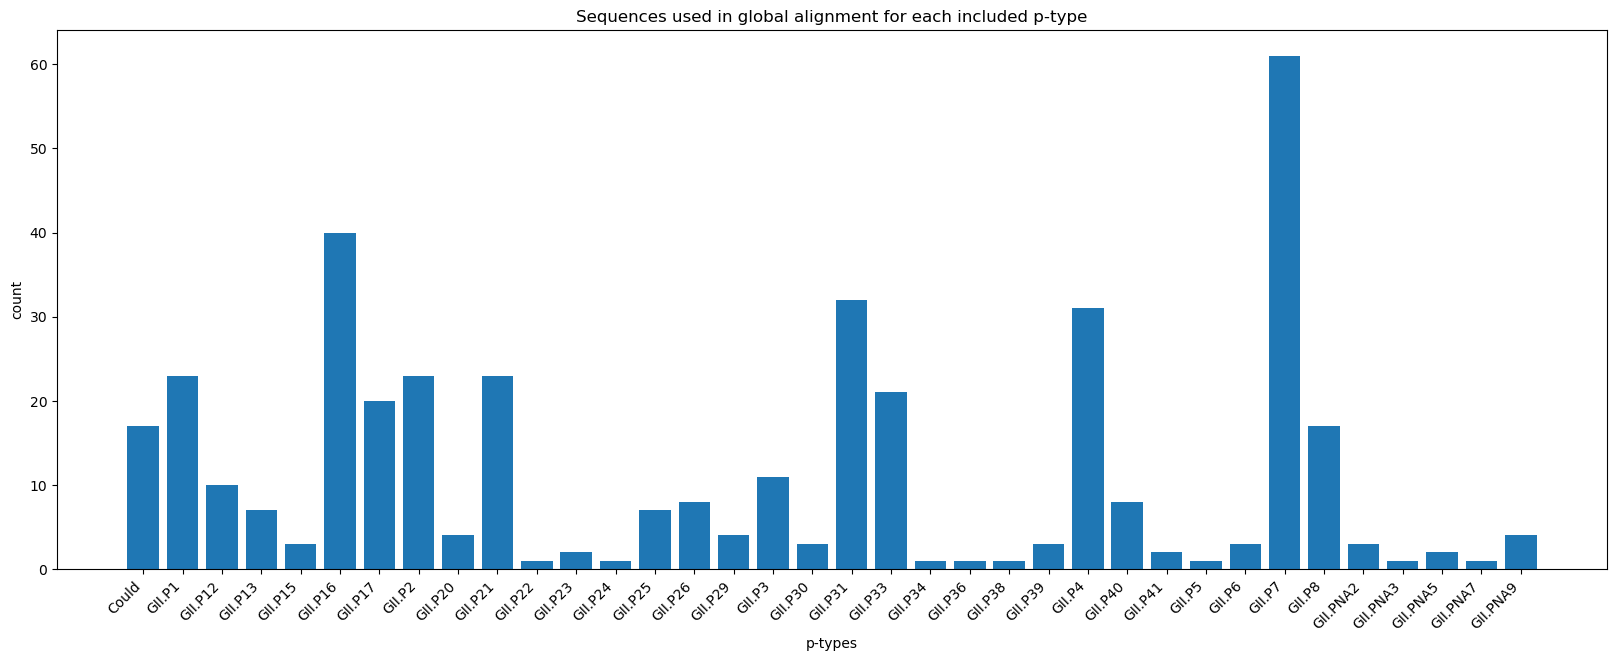

Number of rdrp-sequences in final_rdrp before CD-HIT: 400


In [ ]:
polymerase_before_cdhit_dict = {}

df_pa = pd.read_csv(MERGED_CSV)

for index, row in df_pa.iterrows():
    if row['accession'] in accessions_rdrp_before_cdhit:
        
        if row["p_type"] in polymerase_before_cdhit_dict:
            polymerase_before_cdhit_dict[str(row["p_type"])] += 1
        else:
            polymerase_before_cdhit_dict[str(row["p_type"])] = 1


polymerase_before_cdhit_ordered = OrderedDict(sorted(polymerase_before_cdhit_dict.items(), key = lambda item:item[0]))

plt.figure(figsize=(20, 7))
plt.bar(list(polymerase_before_cdhit_ordered.keys()), list(polymerase_before_cdhit_ordered.values()))
plt.xlabel('p-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('How many of each p-type that are included in rdrp-alignment (before CD-HIT)')
plt.show()


print(f'Number of rdrp-sequences in final_rdrp before CD-HIT: {sum(polymerase_before_cdhit_ordered.values())}')


## För vp1-regionen innan CD-HIT

420


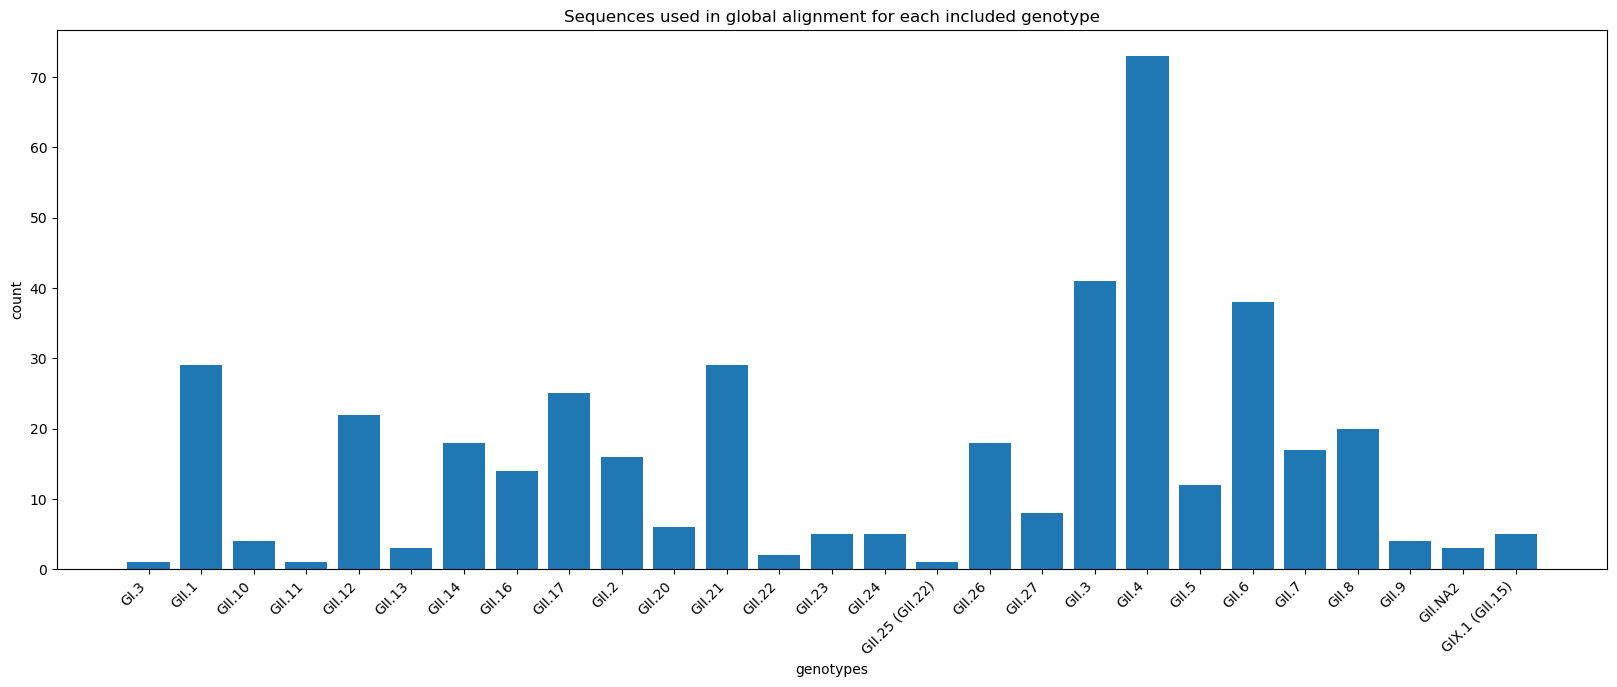

Number of vp1-sequences in final_vp1 before CD-HIT: 420


In [ ]:
vp1_before_cdhit_dict = {}

df_pa = pd.read_csv(MERGED_CSV)

for index, row in df_pa.iterrows():
    if row['accession'] in accessions_vp1_before_cdhit:
        
        if row["genotype"] in vp1_before_cdhit_dict:
            vp1_before_cdhit_dict[str(row["genotype"])] += 1
        else:
            vp1_before_cdhit_dict[str(row["genotype"])] = 1


print(sum(vp1_before_cdhit_dict.values()))
vp1_before_cdhit_ordered = OrderedDict(sorted(vp1_before_cdhit_dict.items(), key = lambda item:item[0]))


plt.figure(figsize=(20, 7))
plt.bar(list(vp1_before_cdhit_ordered.keys()), list(vp1_before_cdhit_ordered.values()))
plt.xlabel('genotypes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('How many of each genotype that are included in vp1-alignment (before CD-HIT)')
plt.show()


print(f'Number of vp1-sequences in final_vp1 before CD-HIT: {sum(vp1_before_cdhit_ordered.values())}')

## För RDRP-alignment (rdrp-regioner) efter CD-HIT

In [287]:
accessions_polymerase_after_cdhit = set()

df_pa = pd.read_csv(POLYMERASE_ACCESSIONS)

print(len(df_pa))
for index, row in df_pa.iterrows():
    # print(row)
    # print()
    accessions_polymerase_after_cdhit.add(row['accession'])

print(len(accessions_polymerase_after_cdhit))

###BERÄKNAR ANTAL

polymerase_dict_after_cdhit = {}

df = pd.read_csv(MERGED_CSV)

for index, row in df.iterrows():
    if row['accession'] in accessions_polymerase_after_cdhit:
        
        if row["p_type"] in polymerase_dict_after_cdhit:
            polymerase_dict_after_cdhit[str(row["p_type"])] += 1
        else:
            polymerase_dict_after_cdhit[str(row["p_type"])] = 1
    


317
317


Number of rdrp-sequences in final_rdrp after CD-HIT: 317


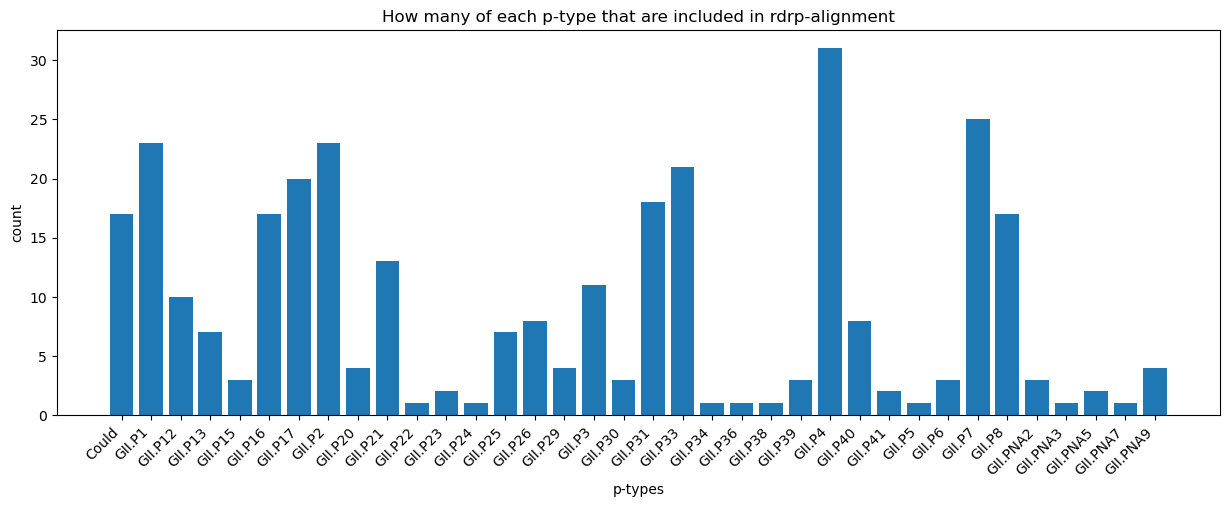

In [288]:
print(f'Number of rdrp-sequences in final_rdrp after CD-HIT: {sum(polymerase_dict_after_cdhit.values())}')

polymerase_after_cdhit_ordered = OrderedDict(sorted(polymerase_dict_after_cdhit.items(), key = lambda item:item[0]))

plt.figure(figsize=(15, 5))
plt.bar(list(polymerase_after_cdhit_ordered.keys()), list(polymerase_after_cdhit_ordered.values()))
plt.xlabel('p-types')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('How many of each p-type that are included in rdrp-alignment')
plt.show()

## För vp1_regioner efter CD-HIT

In [289]:
accessions_vp1_after_cdhit = set()

df_pa_vp1 = pd.read_csv(VP1_ACCESSIONS)

print(len(df_pa_vp1))
for index, row in df_pa_vp1.iterrows():
    accessions_vp1_after_cdhit.add(row['accession'])

print(len(accessions_vp1_after_cdhit))

###BERÄKNAR ANTAL

vp1_dict = {}

df = pd.read_csv(MERGED_CSV)

for index, row in df.iterrows():
    if row['accession'] in accessions_vp1_after_cdhit:
        
        if row["genotype"] in vp1_dict:
            vp1_dict[str(row["genotype"])] += 1
        else:
            vp1_dict[str(row["genotype"])] = 1
    

327
327


Number of vp1-sequences in final_vp1 after CD-HIT: 327


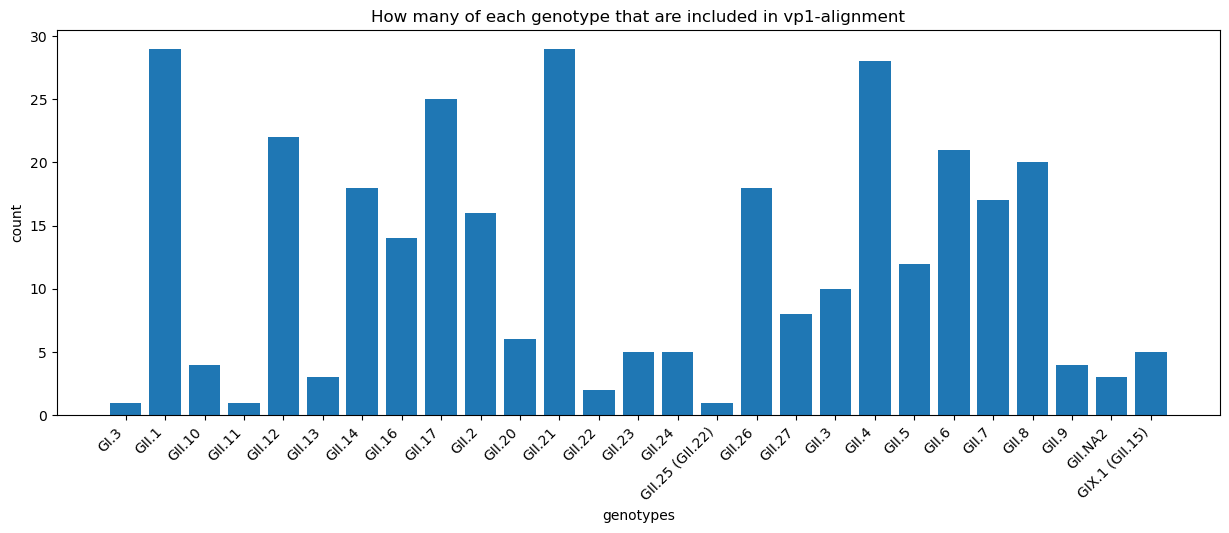

In [290]:
vp1_after_cdhit_ordered = OrderedDict(sorted(vp1_dict.items(), key = lambda item:item[0]))

print(f'Number of vp1-sequences in final_vp1 after CD-HIT: {sum(vp1_after_cdhit_ordered.values())}')

plt.figure(figsize=(15, 5))
plt.bar(list(vp1_after_cdhit_ordered.keys()), list(vp1_after_cdhit_ordered.values()))
plt.xlabel('genotypes')
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('How many of each genotype that are included in vp1-alignment')
plt.show()

__________________________________---